In [17]:
!pip install h5py keras tensorflow 

  Using cached protobuf-5.29.5-cp310-abi3-win_amd64.whl.metadata (592 bytes)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached werkzeug-3.1.3-py3-none-any.whl.metadata (3.7 kB)
   ---------------------------------------- 0.0/375.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/375.9 MB 2.0 MB/s eta 0:03:10
   ---------------------------------------- 0.2/375.9 MB 2.9 MB/s eta 0:02:11
   ---------------------------------------- 1.0/375.9 MB 8.1 MB/s eta 0:00:47
   ---------------------------------------- 1.9/375.9 MB 10.8 MB/s eta 0:00:35
   ---------------------------------------- 3.3/375.9 MB 15.0 MB/s eta 0:00:25
   ---------------------------------------- 4.4/375.9 MB 16.6 MB/s eta 0:00:23
    --------------------------------------- 6.0/375.9 MB 19.1 MB/s eta 0:00:20
    --------------------------------------- 7.2/375.9 MB 19.9 MB/s eta 0:00:19
    --------------------------------------- 9.2/375.9 MB 22.6 MB/s eta 0:00:17
   - --------


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import h5py
import numpy as np 
import matplotlib.pyplot as plt

In [13]:

def load_dataset():
    fn = 'train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) # your train set features
    Y_train = np.array(train_dataset["train_set_y"][:]) # your train set labels

    fn = 'test_signs.h5'
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) # your test set features
    Y_test = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    Y_train = Y_train.reshape((1, Y_train.shape[0]))
    Y_test = Y_test.reshape((1, Y_test.shape[0]))
    
    return X_train, Y_train, X_test, Y_test, classes
train_data, train_labels, test_data, test_labels, classes = load_dataset()

print ('train_data.shape=', train_data.shape)
print ('train_labels.shape=',  train_labels.shape)
print ('test_data.shape=', test_data.shape)
print ('test_labels.shape=', test_labels.shape)

train_data.shape= (1080, 64, 64, 3)
train_labels.shape= (1, 1080)
test_data.shape= (120, 64, 64, 3)
test_labels.shape= (1, 120)


In [14]:
def display_samples_in_grid(X, n_rows, n_cols= None, y = None ):
    if n_cols is None:
        n_cols= n_rows
    indices = np.random.randint(0, len(X),n_rows*n_cols)
    for i in range (n_rows):
        for j in range (n_cols):
            index = n_cols*i+j
            ax = plt.subplot(n_rows,n_cols,index+1)
            ax.imshow(X[indices[index]], cmap='Greys')
            if not (y is None):
                plt.title(y[indices[index]])
            plt.axis('off')

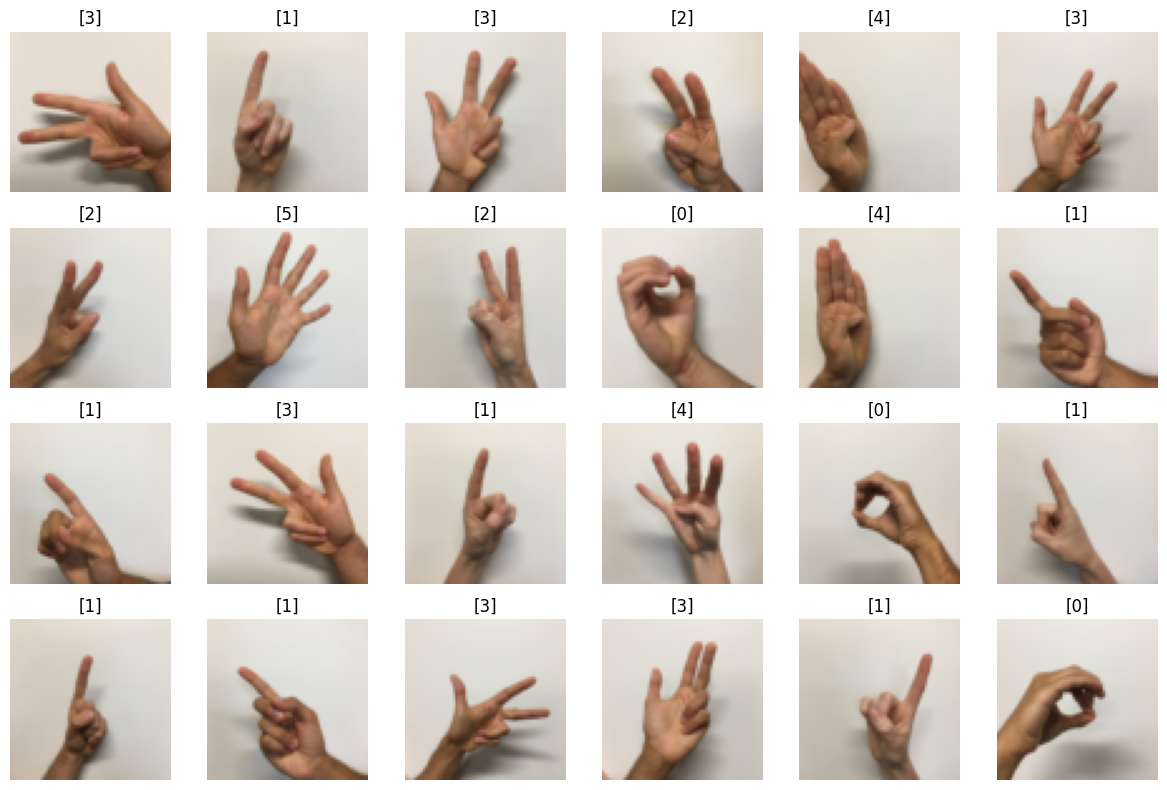

In [15]:
plt.figure(figsize= (12,8))
display_samples_in_grid(train_data, n_rows=4, n_cols=6, y= train_labels.T)
plt.tight_layout(h_pad=1, w_pad=1)

In [18]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
def load_dataset():
    fn = 'train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) 
    Y_train = np.array(train_dataset["train_set_y"][:]) 

    fn = 'test_signs.h5'
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) 
    Y_test = np.array(test_dataset["test_set_y"][:]) 

    classes = np.array(test_dataset["list_classes"][:]) 
    
    Y_train = Y_train.reshape((Y_train.shape[0],))  
    Y_test = Y_test.reshape((Y_test.shape[0],))
    
    return X_train, Y_train, X_test, Y_test, classes

X_train, Y_train, X_test, Y_test, classes = load_dataset()

print('X_train.shape =', X_train.shape)
print('Y_train.shape =', Y_train.shape)
print('X_test.shape =', X_test.shape)
print('Y_test.shape =', Y_test.shape)

X_train = X_train / 255.
X_test = X_test / 255.

num_classes = len(classes)
Y_train_oh = to_categorical(Y_train, num_classes)
Y_test_oh = to_categorical(Y_test, num_classes)

def build_model(num_hidden_layers=1, activation='relu', dropout_rate=0.0):
    model = Sequential()
    model.add(Flatten(input_shape=X_train.shape[1:]))  
    
    for _ in range(num_hidden_layers):
        model.add(Dense(128, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    

    model.add(Dense(num_classes, activation='softmax'))
    
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model(num_hidden_layers=1, activation='relu', dropout_rate=0.0)
history = model.fit(X_train, Y_train_oh, epochs=20, batch_size=64, validation_split=0.2)

test_loss, test_acc = model.evaluate(X_test, Y_test_oh)
print(f'Test accuracy: {test_acc:.4f}')



X_train.shape = (1080, 64, 64, 3)
Y_train.shape = (1080,)
X_test.shape = (120, 64, 64, 3)
Y_test.shape = (120,)


d:\python\python_3.11.8\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1669 - loss: 12.2779 - val_accuracy: 0.1806 - val_loss: 3.1065
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1976 - loss: 2.5000 - val_accuracy: 0.1481 - val_loss: 1.7784
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2493 - loss: 1.7635 - val_accuracy: 0.2639 - val_loss: 1.7496
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2230 - loss: 1.7581 - val_accuracy: 0.3009 - val_loss: 1.7277
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2807 - loss: 1.7255 - val_accuracy: 0.2454 - val_loss: 1.7326
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2870 - loss: 1.7130 - val_accuracy: 0.3380 - val_loss: 1.6927
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2808 - loss: 1.6931 - val_accuracy: 0.3148 - val_loss: 1.6796
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2695 - loss: 1.6950 - val_accuracy: 0.3333 - 

In [20]:
def load_dataset():
    fn = 'train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) 
    Y_train = np.array(train_dataset["train_set_y"][:]) 

    fn = 'test_signs.h5'
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) 
    Y_test = np.array(test_dataset["test_set_y"][:]) 

    classes = np.array(test_dataset["list_classes"][:]) 
    
    Y_train = Y_train.reshape((Y_train.shape[0],))  
    Y_test = Y_test.reshape((Y_test.shape[0],))
    
    return X_train, Y_train, X_test, Y_test, classes

X_train, Y_train, X_test, Y_test, classes = load_dataset()

print('X_train.shape =', X_train.shape)
print('Y_train.shape =', Y_train.shape)
print('X_test.shape =', X_test.shape)
print('Y_test.shape =', Y_test.shape)

X_train = X_train / 255.
X_test = X_test / 255.

num_classes = len(classes)
Y_train_oh = to_categorical(Y_train, num_classes)
Y_test_oh = to_categorical(Y_test, num_classes)

def build_model(num_hidden_layers=1, activation='relu', dropout_rate=0.0):
    model = Sequential()
    model.add(Flatten(input_shape=X_train.shape[1:]))  
    
    for _ in range(num_hidden_layers):
        model.add(Dense(128, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    

    model.add(Dense(num_classes, activation='softmax'))
    
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model(num_hidden_layers=3, activation='sigmoid', dropout_rate=0.0)
history = model.fit(X_train, Y_train_oh, epochs=20, batch_size=64, validation_split=0.2)

test_loss, test_acc = model.evaluate(X_test, Y_test_oh)
print(f'Test accuracy: {test_acc:.4f}')

X_train.shape = (1080, 64, 64, 3)
Y_train.shape = (1080,)
X_test.shape = (120, 64, 64, 3)
Y_test.shape = (120,)
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.1433 - loss: 1.8512 - val_accuracy: 0.1713 - val_loss: 1.8111
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1575 - loss: 1.8147 - val_accuracy: 0.1528 - val_loss: 1.8060
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1763 - loss: 1.8008 - val_accuracy: 0.1296 - val_loss: 1.7948
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1409 - loss: 1.7972 - val_accuracy: 0.1528 - val_loss: 1.8019
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1791 - loss: 1.7960 - val_accuracy: 0.1806 - val_loss: 1.7883
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1561 - loss: 1.7999 - val_accuracy: 0.1296 - val_loss: 1.8020
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1658 - loss: 1.7946 - val_accuracy: 0.1852 - val_loss: 1.7935

In [ ]:
def load_dataset():
    fn = 'train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) 
    Y_train = np.array(train_dataset["train_set_y"][:]) 

    fn = 'test_signs.h5'
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) 
    Y_test = np.array(test_dataset["test_set_y"][:]) 

    classes = np.array(test_dataset["list_classes"][:]) 
    
    Y_train = Y_train.reshape((Y_train.shape[0],))  
    Y_test = Y_test.reshape((Y_test.shape[0],))
    
    return X_train, Y_train, X_test, Y_test, classes

X_train, Y_train, X_test, Y_test, classes = load_dataset()

print('X_train.shape =', X_train.shape)
print('Y_train.shape =', Y_train.shape)
print('X_test.shape =', X_test.shape)
print('Y_test.shape =', Y_test.shape)

X_train = X_train / 255.
X_test = X_test / 255.

num_classes = len(classes)
Y_train_oh = to_categorical(Y_train, num_classes)
Y_test_oh = to_categorical(Y_test, num_classes)

def build_model(num_hidden_layers=1, activation='relu', dropout_rate=0.0):
    model = Sequential()
    model.add(Flatten(input_shape=X_train.shape[1:]))  
    
    for _ in range(num_hidden_layers):
        model.add(Dense(128, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    

    model.add(Dense(num_classes, activation='softmax'))
    
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model(num_hidden_layers=4, activation='tanh', dropout_rate=0.0)
history = model.fit(X_train, Y_train_oh, epochs=20, batch_size=64, validation_split=0.2)

test_loss, test_acc = model.evaluate(X_test, Y_test_oh)
print(f'Test accuracy: {test_acc:.4f}')